In [4]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations
print('gsw version:', gsw.__version__)

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

gsw version: 3.6.21


# Water Level Data from OWLR at Veteran's Park Retention Pond

In the spreadsheet this is shown at rainfall_0001 data. 

In [5]:


# Paths & time window

data_dir  = "Data"
owlr_path = os.path.join(data_dir, "waterLevel_OWLR_VP_06152026.csv")

start_time = pd.Timestamp("2026-06-07 13:00:00")
end_time   = pd.Timestamp("2026-06-15 08:00:00")


# Load OWLR (rainfall_0001 rows only)

cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw = owlr_raw[owlr_raw["data_type"] == "rainfall_0001"].copy()

owlr_raw["OWLR_value_cm"] = pd.to_numeric(
    owlr_raw["OWLR_value_cm"].fillna(owlr_raw["epoch"].str.split(",").str[1]),
    errors="coerce"
)

owlr_raw["WSE_OWLR_cm"] = 827.8368 - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
].copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")
owlr = owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"].mean()

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall_0001) hourly points: {len(owlr)}")
print(owlr.tail())


Window: 2026-06-07 13:00:00 to 2026-06-15 08:00:00
OWLR (rainfall_0001) hourly points: 187
         timestamp_hour  WSE_OWLR_cm
182 2026-06-15 03:00:00    697.72846
183 2026-06-15 04:00:00    704.90763
184 2026-06-15 05:00:00    710.62013
185 2026-06-15 06:00:00    711.54791
186 2026-06-15 07:00:00    710.74374


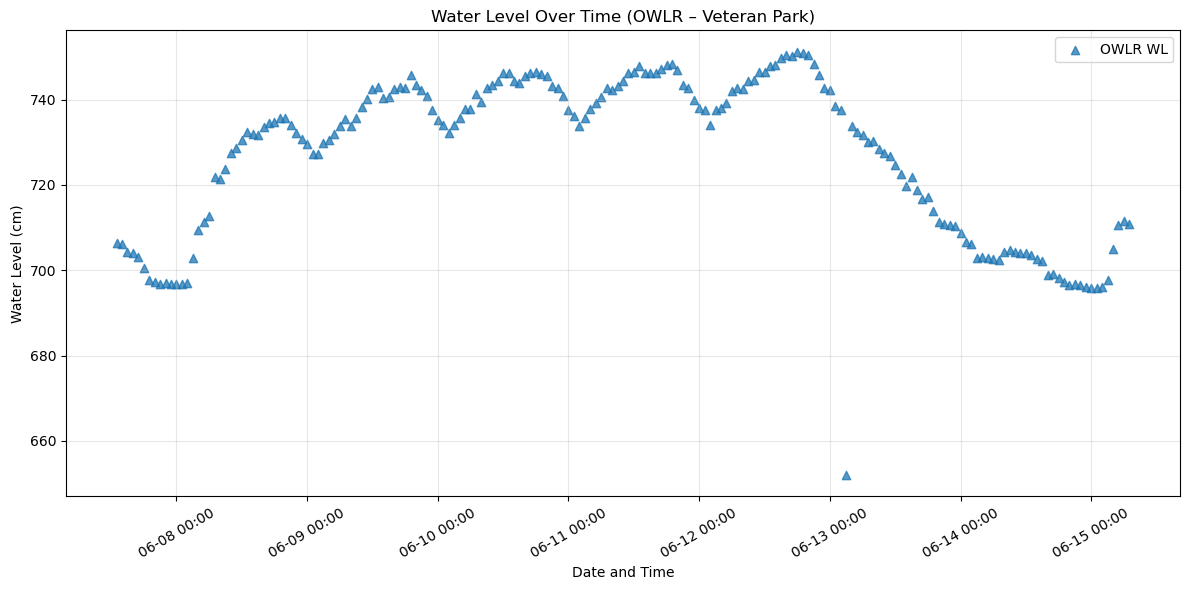

OWLR points shown: 187


In [6]:

# -----------------------------
# Plot OWLR hourly water level
# -----------------------------
if 'owlr' not in globals():
    raise ValueError('Run the data-loading cell first.')

import matplotlib.dates as mdates

owlr_plot = owlr.sort_values('timestamp_hour').copy()

plt.figure(figsize=(12, 6))

plt.scatter(
    owlr_plot['timestamp_hour'],
    owlr_plot['WSE_OWLR_cm'],
    s=36, marker='^', alpha=0.75, label='OWLR WL'
)

plt.title('Water Level Over Time (OWLR – Veteran Park)')
plt.xlabel('Date and Time')
plt.ylabel('Water Level (cm)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=30)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'OWLR points shown: {len(owlr_plot)}')
